In [2]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import spearmanr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Configuration and paths
mac = 20

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(['ENSG00000131471', 'ENSG00000084674'])),

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .unique()
)

anno

[===========================================================>] Completed 7,370,308,270 of 7,370,308,270 bytes (100%) /home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquett


five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,absplice2_max,encode_pels,loftee_hc,encode_tf,consequence_splice_donor_variant,consequence_frameshift_variant,ted_domain,gpn_score,encode_pls,mobi_curated_disorder_priority,consequence_stop_gained,low_complexity_domain,id,five_prime_utr_variant_consequence_uaug_lost,consequence_synonymous_variant,consequence_missense_variant,mobi_lip_full,am_pathogenicity,five_prime_utr_variant_consequence_ustop_lost,consequence_stop_lost,consequence_start_lost,esmscoremissense,aparent2,delta_score,consequence_splice_acceptor_variant,pangolin_score,verphylop,abexp_min,abexp_abs_max,region,promoterai,loftee_lc,five_prime_utr_variant_consequence_uaug_gained,encode_dels,cadd_raw
u8,f32,f32,bool,i8,bool,i8,i8,bool,f32,bool,bool,i8,bool,str,u8,i8,i8,bool,f32,u8,i8,i8,f32,f32,f32,i8,f32,f32,f32,f32,str,f32,i8,u8,bool,f32
0,0.0,0.000033,false,0,false,0,0,false,-1.41,false,false,0,false,"""chr2:21041905:T:C""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.237,-0.018821,0.018821,"""ENSG00000084674""",0.0,0,0,false,0.464297
0,0.0,0.000033,false,0,false,0,0,false,-1.56,false,false,0,false,"""chr17:42856777:C:T""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-1.05,-0.00599,0.00599,"""ENSG00000131471""",0.0,0,0,true,-0.445657
0,0.0,0.000033,false,0,false,0,0,false,-1.39,false,false,0,false,"""chr2:21035478:A:G""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.503,-0.019552,0.019552,"""ENSG00000084674""",0.0,0,0,false,-0.210185
0,0.0,0.000033,false,0,false,0,0,false,-1.68,false,false,0,false,"""chr2:21039940:G:T""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,0.294,-0.006358,0.006774,"""ENSG00000084674""",0.0,0,0,false,0.181631
0,0.0,0.0,false,0,false,0,0,false,-1.64,false,false,0,false,"""chr2:20996511:G:T""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,1.83,0.0,0.0,"""ENSG00000084674""",0.0,0,0,false,0.660005
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0.0,0.000033,false,0,false,0,0,false,0.06,false,false,0,false,"""chr2:21027382:C:T""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-2.28,-0.019552,0.019552,"""ENSG00000084674""",0.0,0,0,true,-0.092665
0,0.0,0.0,true,0,false,0,0,false,-1.53,false,false,0,false,"""chr2:21045243:G:C""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.849,0.0,0.0,"""ENSG00000084674""",0.0,0,0,false,0.159903
0,0.0,0.000033,false,0,true,0,0,false,-1.4,false,false,0,false,"""chr2:21003887:T:A""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.201,-0.006261,0.006871,"""ENSG00000084674""",0.0,0,0,false,-0.01333


# Olink scatter plot

In [5]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

olink_appv

[===========================================================>] Completed 100,324,032 of 100,324,032 bytes (100%) /home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquett


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr17:42847512:G:A""","""ENSG00000131471_olink""",0.647733,1
"""chr17:42854956:C:T""","""ENSG00000131471_olink""",0.14298,1
"""chr17:42848897:C:G""","""ENSG00000131471_olink""",-0.639064,2
"""chr17:42848090:T:TTTA""","""ENSG00000131471_olink""",-0.595697,2
"""chr17:42859525:C:T""","""ENSG00000131471_olink""",0.692828,1
…,…,…,…
"""chr17:42852113:C:T""","""ENSG00000131471_olink""",-0.652947,1
"""chr17:42846621:C:T""","""ENSG00000131471_olink""",1.215292,1
"""chr17:42856030:T:TGTC""","""ENSG00000131471_olink""",-0.740016,1


In [6]:
olink_plot_df = (
    anno
    .join(
        olink_appv, on='id', how='inner'
    )
)

olink_plot_df

five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,absplice2_max,encode_pels,loftee_hc,encode_tf,consequence_splice_donor_variant,consequence_frameshift_variant,ted_domain,gpn_score,encode_pls,mobi_curated_disorder_priority,consequence_stop_gained,low_complexity_domain,id,five_prime_utr_variant_consequence_uaug_lost,consequence_synonymous_variant,consequence_missense_variant,mobi_lip_full,am_pathogenicity,five_prime_utr_variant_consequence_ustop_lost,consequence_stop_lost,consequence_start_lost,esmscoremissense,aparent2,delta_score,consequence_splice_acceptor_variant,pangolin_score,verphylop,abexp_min,abexp_abs_max,region,promoterai,loftee_lc,five_prime_utr_variant_consequence_uaug_gained,encode_dels,cadd_raw,phenotype,mean_pheno_value,n_individuals
u8,f32,f32,bool,i8,bool,i8,i8,bool,f32,bool,bool,i8,bool,str,u8,i8,i8,bool,f32,u8,i8,i8,f32,f32,f32,i8,f32,f32,f32,f32,str,f32,i8,u8,bool,f32,str,f32,i32
0,0.0,0.00235,false,0,false,0,0,false,-0.83,false,false,0,false,"""chr17:42854273:C:T""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.723,-0.01521,0.525604,"""ENSG00000131471""",0.0134,0,0,false,-0.31021,"""ENSG00000131471_olink""",0.365787,2
0,0.0,0.0,false,0,false,0,0,false,-1.1,false,false,0,false,"""chr17:42847979:T:C""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,0.327,0.0,0.002469,"""ENSG00000131471""",0.0,0,0,false,0.286487,"""ENSG00000131471_olink""",1.090186,1
0,0.0,0.0,false,0,false,0,0,false,-0.82,false,false,0,false,"""chr17:42846880:A:G""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,0.505,0.0,0.002667,"""ENSG00000131471""",0.0,0,0,true,0.544201,"""ENSG00000131471_olink""",-2.117289,1
0,0.12,0.000033,false,0,false,0,0,true,-6.21,false,false,0,false,"""chr17:42851611:C:G""",0,0,1,false,0.0974,0,0,0,-3.53,0.0,0.0,0,0.0,1.242,-0.015385,0.015385,"""ENSG00000131471""",0.0001,0,0,false,3.081669,"""ENSG00000131471_olink""",-2.141997,1
0,0.04,0.000152,false,0,false,0,0,false,-3.17,false,false,0,false,"""chr17:42851440:G:A""",0,0,1,false,0.0753,0,0,0,-3.612,0.0,0.0,0,0.0,0.886,-0.063002,0.063002,"""ENSG00000131471""",-0.0206,0,0,false,0.775999,"""ENSG00000131471_olink""",-0.480882,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0.0,0.0,false,0,false,0,0,false,-1.86,false,false,0,false,"""chr17:42848276:G:A""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,0.954,0.0,0.002372,"""ENSG00000131471""",0.0,0,0,false,0.454249,"""ENSG00000131471_olink""",-1.019841,1
0,0.0,0.0,false,0,false,0,0,false,-0.88,false,false,0,false,"""chr17:42848568:T:C""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.36,0.0,0.002469,"""ENSG00000131471""",0.0,0,0,true,0.046635,"""ENSG00000131471_olink""",-0.117794,2
0,0.0,0.000033,false,0,false,0,0,false,-1.03,false,false,0,false,"""chr17:42857067:A:G""",0,0,0,false,0.0,0,0,0,0.0,0.0,0.0,0,0.0,-0.646,-0.00599,0.00599,"""ENSG00000131471""",0.0,0,0,false,-0.011304,"""ENSG00000131471_olink""",-1.417526,2


In [7]:
# Select annotation to plot
selected_annotation = 'am_pathogenicity'

# Look up color and label from config
_anno_row = anno_config_df.filter(pl.col('annotation') == selected_annotation)
anno_color = _anno_row['color'][0]
anno_label = _anno_row['label'][0]

print(f"Annotation: {selected_annotation} → {anno_label} (color: {anno_color})")

Annotation: am_pathogenicity → AlphaMissense (color: #feb72d)


Spearman ρ = -0.308 (p = 1.23e-24)


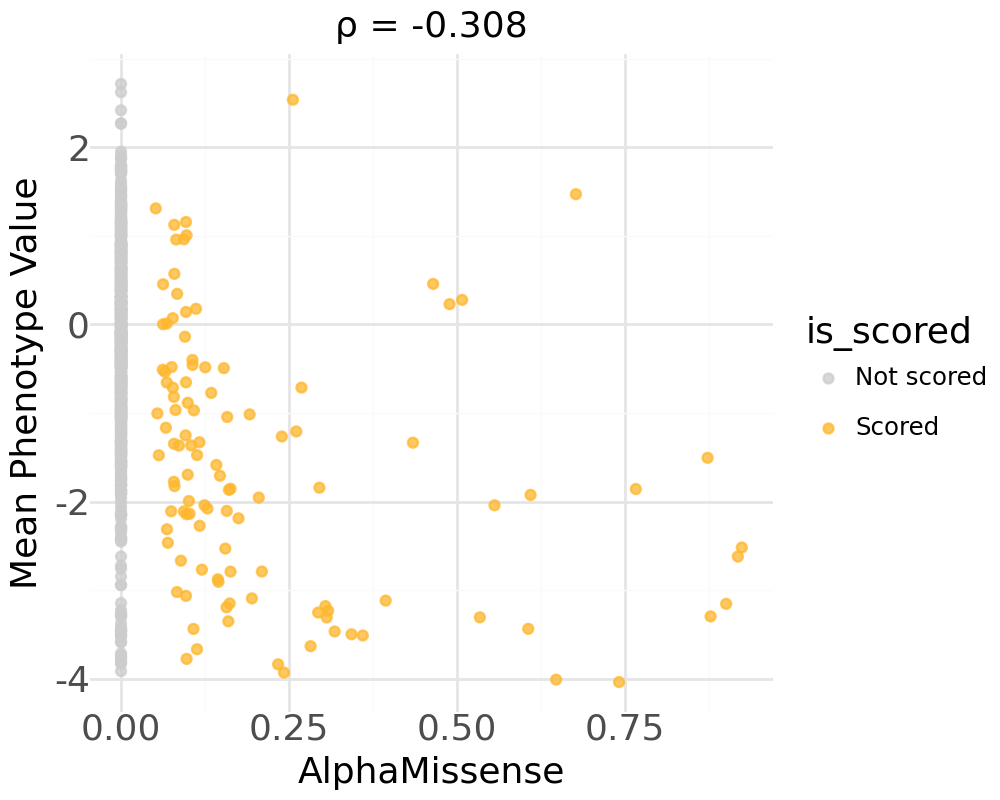

In [8]:
scatter_df = (
    olink_plot_df
    .select(['id', selected_annotation, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        is_scored = pl.when(pl.col(selected_annotation) != 0)
            .then(pl.lit('Scored'))
            .otherwise(pl.lit('Not scored'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    scatter_df[selected_annotation].to_numpy(),
    scatter_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(scatter_df, aes(y='mean_pheno_value', x=selected_annotation))
    + geom_point(aes(color='is_scored'), alpha=0.75, size=1.5)
    + scale_color_manual(
        values={'Scored': anno_color, 'Not scored': '#CCCCCC'},
    )
    + labs(
        x=anno_label,
        y='Mean Phenotype Value',
        title=f'ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(5, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
        legend_position=None
    )
)

Spearman ρ = -0.224 (p = 1.85e-13)


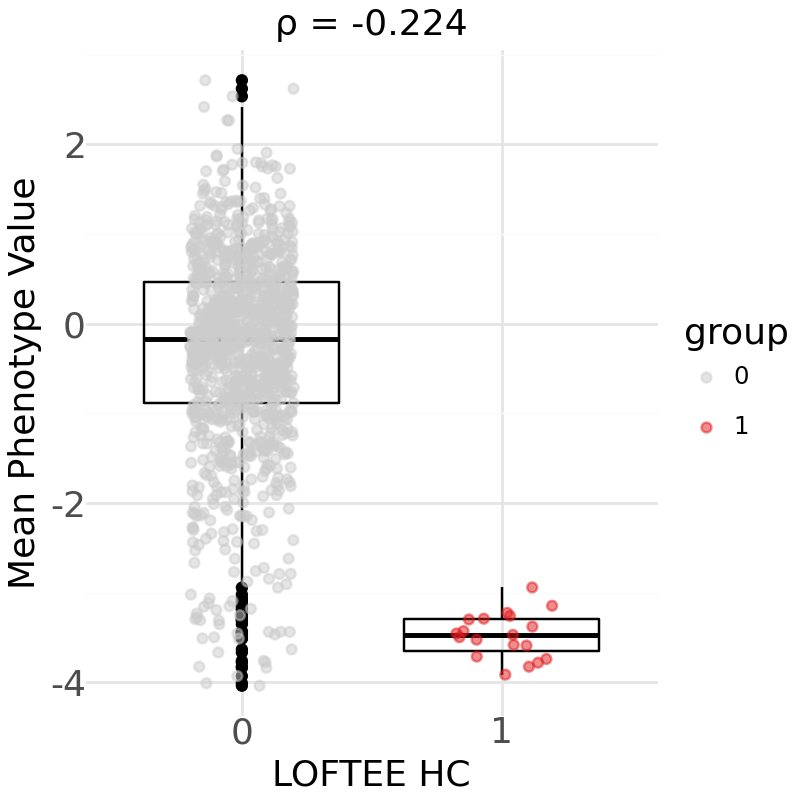

In [45]:
# LOFTEE HC box plot
loftee_anno = 'loftee_hc'
_loftee_row = anno_config_df.filter(pl.col('annotation') == loftee_anno)
loftee_color = _loftee_row['color'][0]
loftee_label = _loftee_row['label'][0]

box_df = (
    olink_plot_df
    .select(['id', loftee_anno, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        group = pl.when(pl.col(loftee_anno) == 1).then(pl.lit('1')).otherwise(pl.lit('0'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    box_df[loftee_anno].to_numpy(),
    box_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(box_df, aes(x='group', y='mean_pheno_value'))
    + geom_boxplot(fill='none', color='black', alpha=0.5)
    + geom_jitter(aes(color='group'), width=0.2, alpha=0.5, size=1.5)
    + scale_color_manual(values={'0': '#CCCCCC', '1': loftee_color})
    + labs(
        x=loftee_label,
        y='Mean Phenotype Value',
        title=f'ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(4, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Pheno scatter plot

In [20]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:21014794:C:T""","""cholesterol_int""",-0.314186,7
"""chr2:21024629:A:C""","""vitamin_d_int""",-0.066045,5
"""chr2:21024629:A:C""","""cholesterol_int""",0.367438,5
"""chr2:21024629:A:C""","""creatinine_int""",-0.762991,5
"""chr2:21019974:GGGTGCAA:G""","""alanine_aminotransferase_int""",-1.304088,7
…,…,…,…
"""chr2:21045674:C:T""","""cholesterol_int""",-0.296104,2
"""chr2:21010186:C:T""","""ldl_direct_int""",-1.135112,3
"""chr2:21045674:C:T""","""standing_height_int""",0.835483,2
